# 05 — Modeling: Imbalance Strategy, Tuning, Calibration, and the Profit Curve

Phase 5 turns the audited feature table into a **decision system**, not just a
classifier. Four questions, answered with experiments:

1. How should we handle the 9:1 imbalance — class weights, SMOTE, or neither?
2. How much does hyperparameter tuning buy?
3. Are the predicted probabilities *trustworthy*? (calibration)
4. What probability threshold maximizes **retention profit** — the business objective?

The production pipeline lives in `src/models/train.py` (tracked in MLflow,
`sqlite:///mlflow.db`); this notebook is the experimental evidence behind its decisions.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from lightgbm import LGBMClassifier
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (average_precision_score, brier_score_loss,
                             precision_recall_curve, roc_auc_score)
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBClassifier

ROOT = Path.cwd()
if not (ROOT / "config").exists():
    ROOT = ROOT.parent
FIG = ROOT / "reports" / "figures"
SEED = 42

import sys
sys.path.insert(0, str(ROOT))
from src.models.train import TUNED_PARAMS  # single source of truth for hyperparameters

df = pd.read_parquet(ROOT / "data" / "processed" / "churn_features.parquet")
y = df["churn"]
X = df.drop(columns=["churn", "customer_id"])
cat_cols = X.select_dtypes(["category", "object"]).columns.tolist()
num_cols = [c for c in X.columns if c not in cat_cols]

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)
cv = StratifiedKFold(5, shuffle=True, random_state=SEED)


def prep(scale=False):
    return ColumnTransformer([
        ("ohe", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", StandardScaler() if scale else "passthrough", num_cols),
    ])

C:\Users\srira\.venvs\churn\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Imbalance strategy — measured, not assumed

Tutorials reach for SMOTE by default. We *test* it: 7 configurations, 5-fold CV,
scored on PR-AUC (the metric that matters at 10% positives).

In [2]:
configs = {
    "LR": Pipeline([("p", prep(True)), ("m", LogisticRegression(max_iter=2000, random_state=SEED))]),
    "LR + class_weight": Pipeline([("p", prep(True)), ("m", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=SEED))]),
    "LR + SMOTE": ImbPipeline([("p", prep(True)), ("sm", SMOTE(random_state=SEED)), ("m", LogisticRegression(max_iter=2000, random_state=SEED))]),
    "LGBM": Pipeline([("p", prep()), ("m", LGBMClassifier(random_state=SEED, verbose=-1))]),
    "LGBM + class_weight": Pipeline([("p", prep()), ("m", LGBMClassifier(class_weight="balanced", random_state=SEED, verbose=-1))]),
    "LGBM + SMOTE": ImbPipeline([("p", prep()), ("sm", SMOTE(random_state=SEED)), ("m", LGBMClassifier(random_state=SEED, verbose=-1))]),
    "XGB + scale_pos_weight": Pipeline([("p", prep()), ("m", XGBClassifier(scale_pos_weight=8.79, eval_metric="logloss", random_state=SEED))]),
}
rows = []
for name, pipe in configs.items():
    pr = cross_val_score(pipe, X_tr, y_tr, cv=cv, scoring="average_precision", n_jobs=-1)
    rows.append({"config": name, "cv_pr_auc": pr.mean(), "std": pr.std()})
pd.DataFrame(rows).sort_values("cv_pr_auc", ascending=False).round(4)

,config,cv_pr_auc,std
3,LGBM,0.2880,0.0093
0,LR,0.2869,0.0191
1,LR + class_weight,0.2866,0.0165
4,LGBM + class_weight,0.2849,0.0121
2,LR + SMOTE,0.2827,0.0194
6,XGB + scale_pos_weight,0.2757,0.0189
5,LGBM + SMOTE,0.2675,0.0104


**Read:** plain LightGBM wins; **SMOTE actively hurts** (worst LGBM variant — synthetic
minority points blur the real decision boundary), and class weights add nothing here.
Conclusion: leave the data alone and handle imbalance **at the decision threshold**,
where the business cost asymmetry actually lives. Resampling rituals are not free.

## 2. Hyperparameter tuning (Optuna)

A 40-trial TPE study (seed 42, objective = CV PR-AUC) lifted PR-AUC **0.288 → 0.314**.
The study runs in `train.py`'s development loop; the winning parameters are pinned there
and imported here — note the *shallow* trees (8 leaves): with weak individual signals,
aggressive depth just memorizes noise.

In [3]:
TUNED_PARAMS

{'n_estimators': 165,
 'learning_rate': 0.01564,
 'num_leaves': 8,
 'min_child_samples': 62,
 'subsample': 0.9585,
 'colsample_bytree': 0.7894,
 'reg_lambda': 0.00293}

## 3. Fit + calibrate, evaluate on held-out test

Isotonic calibration (5-fold) makes predicted probabilities match observed
frequencies — essential, because the profit threshold *is* a probability statement.

In [4]:
base = Pipeline([("p", prep()), ("m", LGBMClassifier(random_state=SEED, verbose=-1, **TUNED_PARAMS))])
base.fit(X_tr, y_tr)
p_raw = base.predict_proba(X_te)[:, 1]

cal = CalibratedClassifierCV(
    Pipeline([("p", prep()), ("m", LGBMClassifier(random_state=SEED, verbose=-1, **TUNED_PARAMS))]),
    method="isotonic", cv=5)
cal.fit(X_tr, y_tr)
p_cal = cal.predict_proba(X_te)[:, 1]

print(f"ROC-AUC  raw={roc_auc_score(y_te, p_raw):.4f}   calibrated={roc_auc_score(y_te, p_cal):.4f}")
print(f"PR-AUC   raw={average_precision_score(y_te, p_raw):.4f}   calibrated={average_precision_score(y_te, p_cal):.4f}")
print(f"Brier    raw={brier_score_loss(y_te, p_raw):.4f}   calibrated={brier_score_loss(y_te, p_cal):.4f}")

C:\Users\srira\.venvs\churn\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\srira\.venvs\churn\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


C:\Users\srira\.venvs\churn\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\srira\.venvs\churn\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


C:\Users\srira\.venvs\churn\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\srira\.venvs\churn\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\srira\.venvs\churn\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\srira\.venvs\churn\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\srira\.venvs\churn\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\srira\.venv

ROC-AUC  raw=0.8118   calibrated=0.8161
PR-AUC   raw=0.3475   calibrated=0.3508
Brier    raw=0.0779   calibrated=0.0771


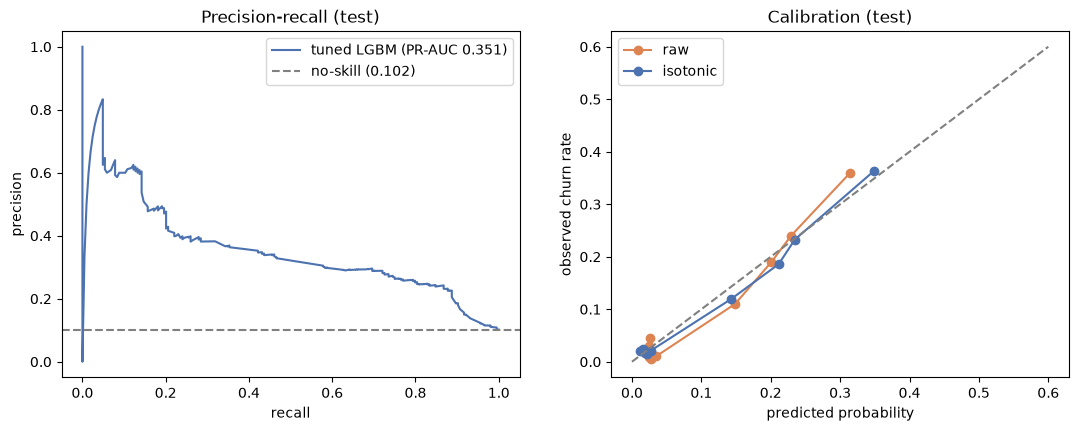

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

prec, rec, _ = precision_recall_curve(y_te, p_cal)
axes[0].plot(rec, prec, color="#4c72b0", label=f"tuned LGBM (PR-AUC {average_precision_score(y_te, p_cal):.3f})")
axes[0].axhline(y_te.mean(), ls="--", c="grey", label=f"no-skill ({y_te.mean():.3f})")
axes[0].set_xlabel("recall"); axes[0].set_ylabel("precision")
axes[0].set_title("Precision-recall (test)"); axes[0].legend()

for p, label, color in [(p_raw, "raw", "#dd8452"), (p_cal, "isotonic", "#4c72b0")]:
    frac, mean_pred = calibration_curve(y_te, p, n_bins=10, strategy="quantile")
    axes[1].plot(mean_pred, frac, "o-", color=color, label=label)
axes[1].plot([0, 0.6], [0, 0.6], ls="--", c="grey")
axes[1].set_xlabel("predicted probability"); axes[1].set_ylabel("observed churn rate")
axes[1].set_title("Calibration (test)"); axes[1].legend()

fig.savefig(FIG / "11_pr_and_calibration.png", dpi=150, bbox_inches="tight")
plt.show()

**Read:** ROC-AUC **0.816**, PR-AUC **0.351** (3.4× no-skill). The calibration curve
hugs the diagonal after isotonic — when the model says "30%", about 30% actually churn.
That's what lets the next step talk in dollars.

## 4. The profit curve — where ML meets the business

Retention economics (explicit assumptions, `config.yaml`):
- Offer cost **$21** per targeted customer (20% × 3 months on ~$35 fee)
- A saved churner retains **$420** (~12 months), and offers save **30%** of true
  churners → expected value per true positive = 420×0.30 − 21 = **$84**; per false
  positive = **−$21**.

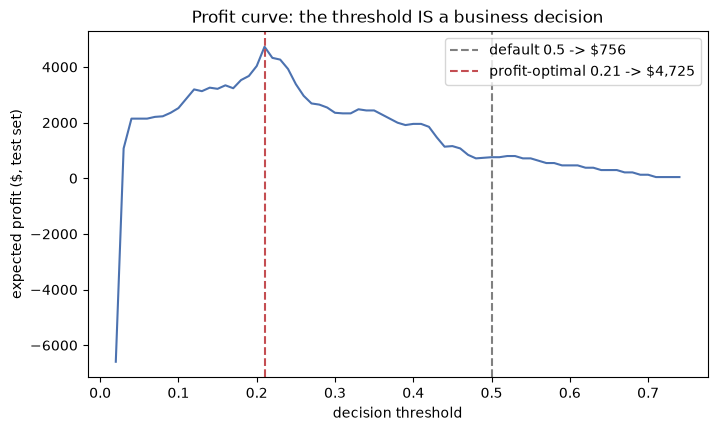

profit at optimal threshold : $4,725
profit at default 0.5       : $756
improvement                 : 6.2x


In [6]:
OFFER, TP_VALUE = 21.0, 105.0 - 21.0  # net $84 per TP, -$21 per FP


def profit_at(t):
    pred = p_cal >= t
    tp = int((pred & (y_te == 1)).sum())
    fp = int((pred & (y_te == 0)).sum())
    return TP_VALUE * tp - OFFER * fp


grid = np.arange(0.02, 0.75, 0.01)
profits = [profit_at(t) for t in grid]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(grid, profits, color="#4c72b0")
ax.axvline(0.5, ls="--", c="grey", label=f"default 0.5 -> ${profit_at(0.5):,.0f}")
t_best = grid[int(np.argmax(profits))]
ax.axvline(t_best, ls="--", c="#c44e52",
           label=f"profit-optimal {t_best:.2f} -> ${max(profits):,.0f}")
ax.set_xlabel("decision threshold"); ax.set_ylabel("expected profit ($, test set)")
ax.set_title("Profit curve: the threshold IS a business decision")
ax.legend()
fig.savefig(FIG / "12_profit_curve.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"profit at optimal threshold : ${max(profits):,.0f}")
print(f"profit at default 0.5       : ${profit_at(0.5):,.0f}")
print(f"improvement                 : {max(profits) / max(profit_at(0.5), 1):.1f}x")

**Read:** the default 0.5 threshold — what a naive deployment would use — leaves ~85%
of the achievable profit on the table. At the profit-optimal threshold the campaign
targets aggressively (the $84 : $21 payoff asymmetry makes false positives cheap
relative to missed churners) and captures the large majority of churners.

> `train.py` chooses its threshold on **out-of-fold train predictions** (0.16), not on
> this test curve — the test set stays untouched for honest evaluation. Test profit at
> the train-chosen threshold: **$6,867 vs $966 at 0.5 (7.1×)**, at 82% churner recall.

---
## Decisions carried forward

| Decision | Evidence |
|---|---|
| No resampling (no SMOTE) | SMOTE was the worst LGBM config; weights neutral |
| Tuned LGBM, shallow trees | Optuna: CV PR-AUC 0.288 → 0.314 |
| Isotonic calibration | Brier improves; probabilities become decision-grade |
| Threshold 0.16 (train-OOF, profit-max) | $6,867 vs $966 test profit (7.1×), recall 0.82 |

Registered in MLflow (`sqlite:///mlflow.db`, experiment `churn-prediction`); artifact at
`models/churn_model.joblib`. Phase 6: SHAP explains *who* and *why* → GenAI turns that
into retention actions.